In [6]:
# importing modules and python libraries
import os 
import numpy as np 
import random
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import shuffle

In [2]:
# Loading dataset
train_path = []
train_label = []
train_dir = r'C:\Users\priya\OneDrive\Desktop\project\Training'
test_dir = r'C:\Users\priya\OneDrive\Desktop\project\Testing'
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_path.append(os.path.join(train_dir,label,image))
        train_label.append(label)
train_path, train_label = shuffle(train_path,train_label)
test_path = []
test_label = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_path.append(os.path.join(test_dir, label, image))
        test_label.append(label)

test_path, test_label = shuffle(test_path, test_label)

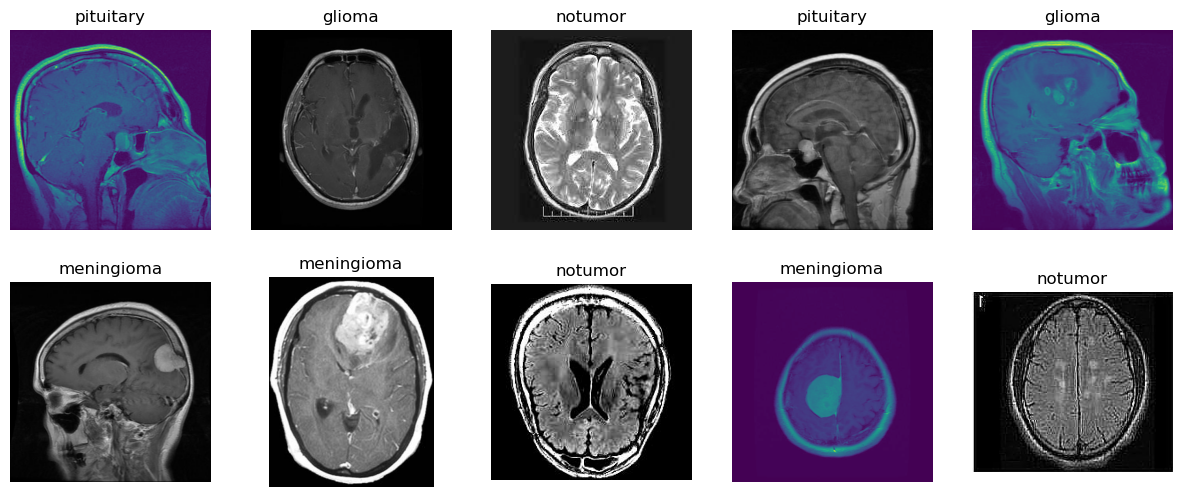

In [3]:
# Data Visulalization 
import random
import matplotlib.pyplot as plt
random_indices = random.sample(range(len(train_path)),10)
fig, axes = plt.subplots(2, 5, figsize=(15,6))
axes = axes.ravel()
for i, inx in enumerate(random_indices):
    img = plt.imread(train_path[inx])
    axes[i].imshow(img)
    axes[i].set_title(train_label[inx])
    axes[i].axis('off')
plt.tight_layout
plt.show()


In [4]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  
    image = np.array(image) / 255.0
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    # Sort to maintain consistent order
    unique_labels = sorted(os.listdir(train_dir))
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  
            yield batch_images, batch_labels  

    

In [5]:
os.listdir(train_dir)
#os.listdir(test_dir)

['glioma', 'meningioma', 'notumor', 'pituitary']

In [6]:
# Model architecture
IMAGE_SIZE = 128  # Image size (adjust based on your requirements)
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 base model
for layer in base_model.layers:
    layer.trainable = False
    
# Set the last few layers of the VGG16 base model to be trainable
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build the final model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  
model.add(base_model)  
model.add(Flatten())  
model.add(Dropout(0.3))  
model.add(Dense(128, activation='relu'))  
model.add(Dropout(0.2))  
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_path) / batch_size)  
epochs = 10

# Train the model
history = model.fit(datagen(train_path, train_label, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)


Epoch 1/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 628s 2s/step - loss: 0.4405 - sparse_categorical_accuracy: 0.8311
Epoch 2/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 879s 3s/step - loss: 0.2353 - sparse_categorical_accuracy: 0.9106 
Epoch 3/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 870s 3s/step - loss: 0.1521 - sparse_categorical_accuracy: 0.9426 
Epoch 4/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 565s 2s/step - loss: 0.1004 - sparse_categorical_accuracy: 0.9605 
Epoch 5/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - loss: 0.0785 - sparse_categorical_accuracy: 0.9700
Epoch 6/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - loss: 0.0647 - sparse_categorical_accuracy: 0.9770
Epoch 7/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 257s 903ms/step - loss: 0.0721 - sparse_categorical_accuracy: 0.9749
Epoch 8/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 265s 928ms/step - loss: 0.0494 - sparse_categorical_accuracy: 0.9844 
Epoch 9/10
285/285 ━━━━━━━━━━━━━━━━━━━━ 256s 897ms/step - loss: 0.0425 - sparse_categorical_accuracy: 0.9851
Epoch 10/10
285/285 ━━━━━━━━━━━━━

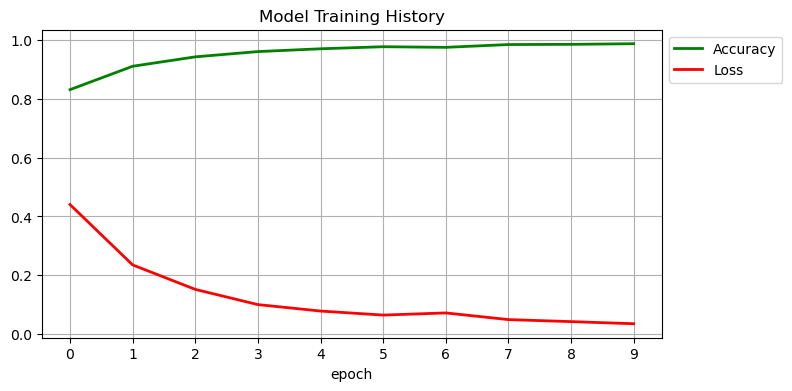

In [7]:
#Train and val plots
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], color='green', linewidth=2)
plt.plot(history.history['loss'], color='red', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(epochs)])
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1,1))
plt.show()

In [8]:
#classfication plot
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
import numpy as np 

test_image=open_images(test_path)
test_label_encode=encode_label(test_label)
model_prediction = model.predict(test_image)
print('Classification Report : ')
print(classification_report(test_label_encode, np.argmax(model_prediction, axis=1)))


41/41 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step
Classification Report : 
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       300
           1       0.97      0.92      0.94       306
           2       1.00      1.00      1.00       405
           3       0.98      0.99      0.98       300

    accuracy                           0.97      1311
   macro avg       0.97      0.97      0.97      1311
weighted avg       0.97      0.97      0.97      1311



Confusion Matrix
[[293   7   0   0]
 [ 18 281   0   7]
 [  1   0 404   0]
 [  2   2   0 296]]


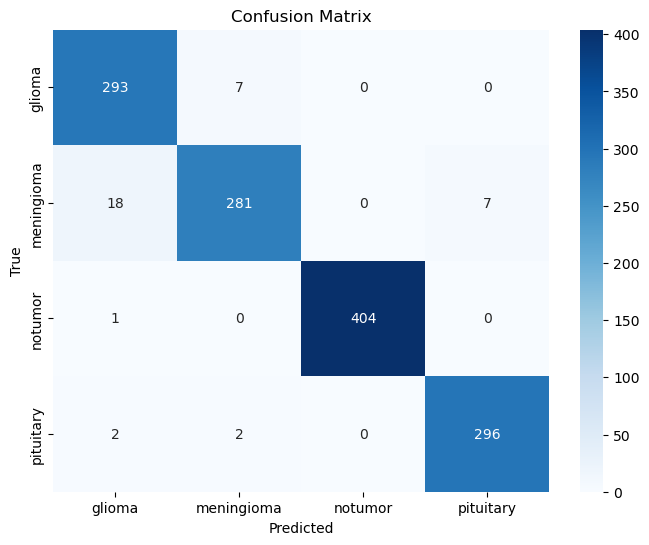

In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_label_encode, np.argmax(model_prediction, axis=1))

print("Confusion Matrix")
print(cm)

plt.figure(figsize=(8,6))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=os.listdir(train_dir),
            yticklabels=os.listdir(train_dir))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [10]:
model.save('Brain.h5')


In [7]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('Brain.h5')        

In [8]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_labels = ['glioma', 'meningioma', 'notumor', 'pituitary']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 792ms/step


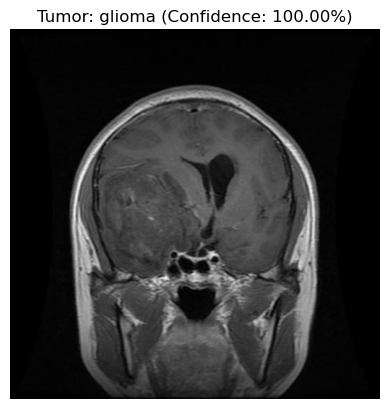

In [5]:
image_path = r'C:\Users\priya\OneDrive\Desktop\project\Testing\glioma\Te-gl_0244.jpg'
detect_and_display(image_path, model)